In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
df = pd.read_csv("S:\AI ML\Machine Learning\Datasets\Algerian_forest_fires_train.csv")

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Sarvadnya\AppData\Local\Temp\ipykernel_19636\4080114785.py:1: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("S:\AI ML\Machine Learning\Datasets\Algerian_forest_fires_train.csv")


In [21]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [22]:
# independent and Dependant features
X = df.drop("FWI", axis=1)
y = df["FWI"]

In [23]:
# Train Test Split
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [25]:
# Feature Selection based on correlation
crr = X_train.corr()

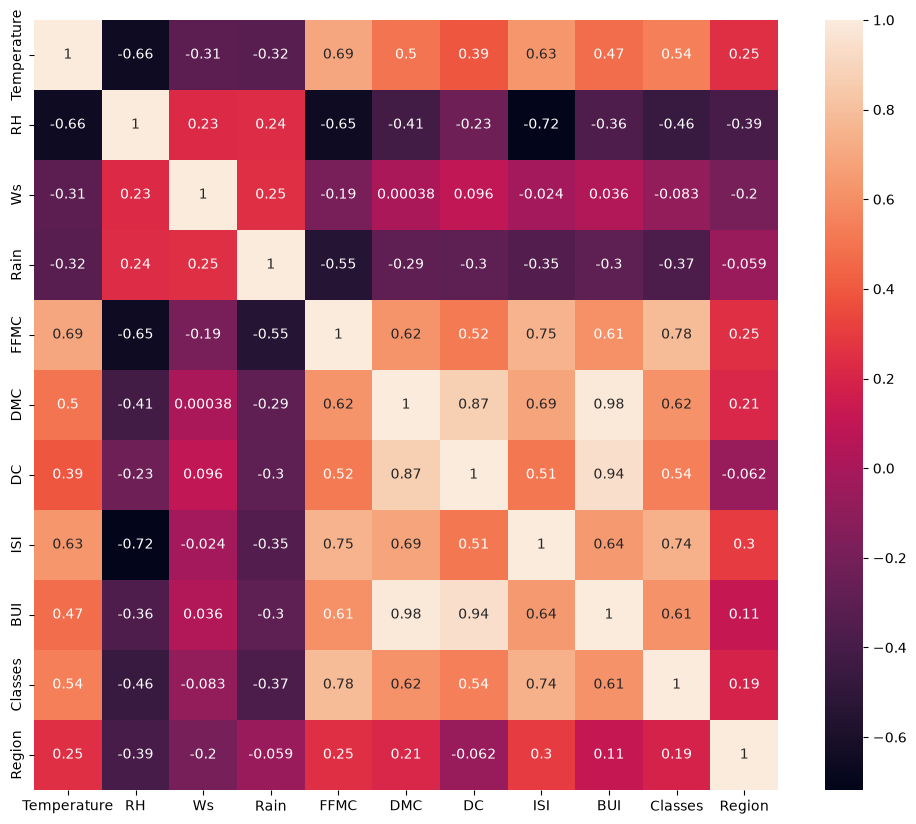

In [26]:
# Checking for multicollinearity
plt.figure(figsize=(12, 10))
sns.heatmap(crr, annot=True)
plt.show()

In [27]:
def correlation(data, thresh):
    col_corr = set()
    corr_matrix = data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > thresh:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [28]:
drop_feature = correlation(X_train, 0.85)

In [29]:
# Drop features whose correlation is beyond thershold
X_train.drop(drop_feature, axis=1, inplace=True)
X_test.drop(drop_feature, axis=1, inplace=True)

In [30]:
# Feature Scaling or Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [31]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

Text(0.5, 1.0, 'X_train After Standardization')

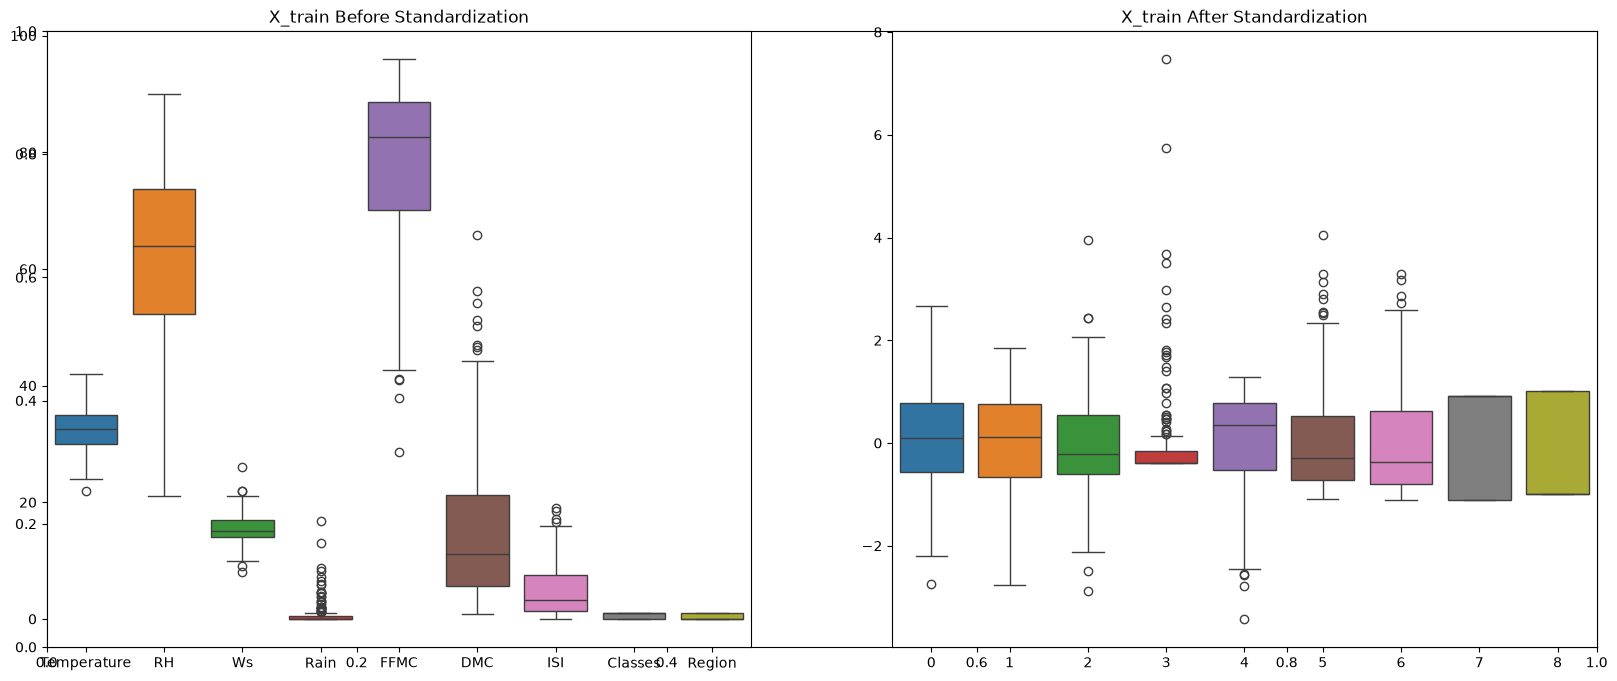

In [33]:
# Box plot to understand Effect of Standard Scaler
plt.subplots(figsize=(20, 8))
plt.subplot(1, 2, 1)
sns.boxplot(X_train)
plt.title("X_train Before Standardization")
plt.subplot(1, 2, 2)
sns.boxplot(X_train_scaled)
plt.title("X_train After Standardization")

# Ridge Regression Model


In [34]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score

rdg = Ridge()
rdg.fit(X_train_scaled, y_train)
y_pred = rdg.predict(X_test_scaled)

Mean Absolute Error: 0.5811107674166778
R Square Score:  0.9833489534582402


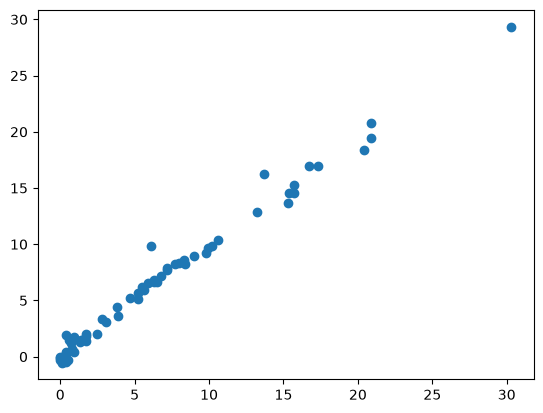

In [35]:
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("R Square Score: ", score)
plt.scatter(y_test, y_pred)

# Pickling the best model

In [ ]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(rdg,open('ridge.pkl','wb'))